In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('C:\\Users\\Admin\\Desktop\\netflix_titles.csv')

In [34]:
print(df.shape)
print(df.info())
print(df.head())

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien 

In [35]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [44]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
print(df[['title','date_added', 'year_added', 'month_added']].head())

                   title date_added  year_added  month_added
0   Dick Johnson Is Dead 2021-09-25      2021.0          9.0
1          Blood & Water 2021-09-24      2021.0          9.0
2              Ganglands 2021-09-24      2021.0          9.0
3  Jailbirds New Orleans 2021-09-24      2021.0          9.0
4           Kota Factory 2021-09-24      2021.0          9.0


In [48]:
df['country'] = df['country'].fillna('Unknown')
print(df['country'].value_counts().head())

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
Name: count, dtype: int64


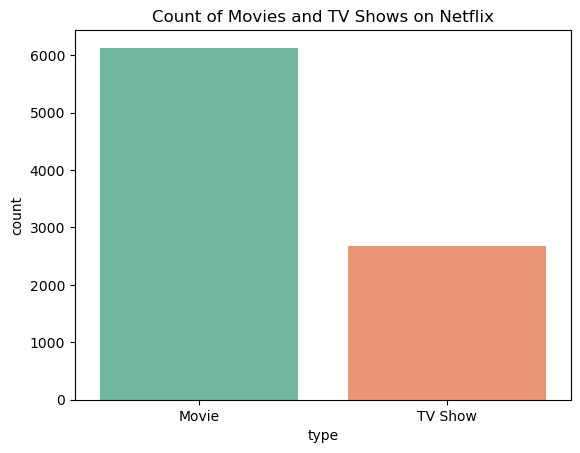

In [50]:
sns.countplot(x='type', data=df, hue='type', palette='Set2', legend=False)
plt.title("Count of Movies and TV Shows on Netflix")
plt.show()

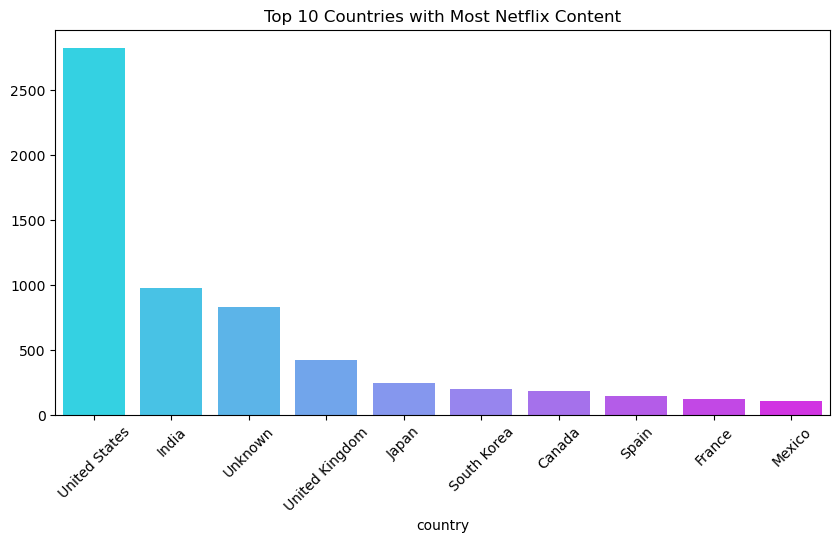

In [54]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.index,y=top_countries.values,hue=top_countries.index,palette='cool')
plt.title("Top 10 Countries with Most Netflix Content")
plt.xticks(rotation=45)
plt.show()

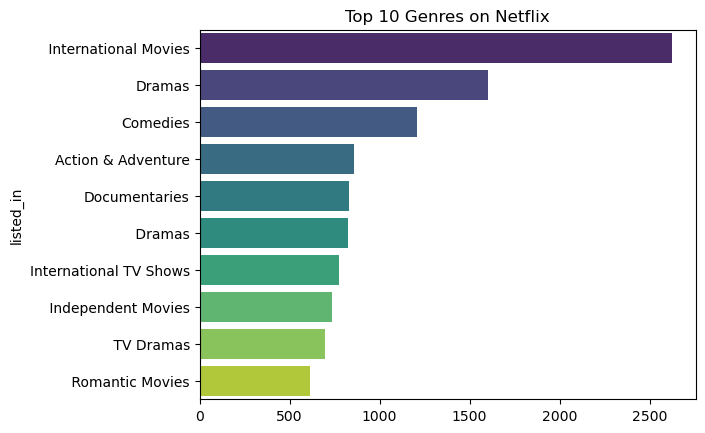

In [56]:
genres = df['listed_in'].str.split(',').explode().value_counts().head(10)
sns.barplot(x=genres.values,
            y=genres.index,
            hue=genres.index,
            palette='viridis',
            legend=False)
plt.title("Top 10 Genres on Netflix")
plt.show()

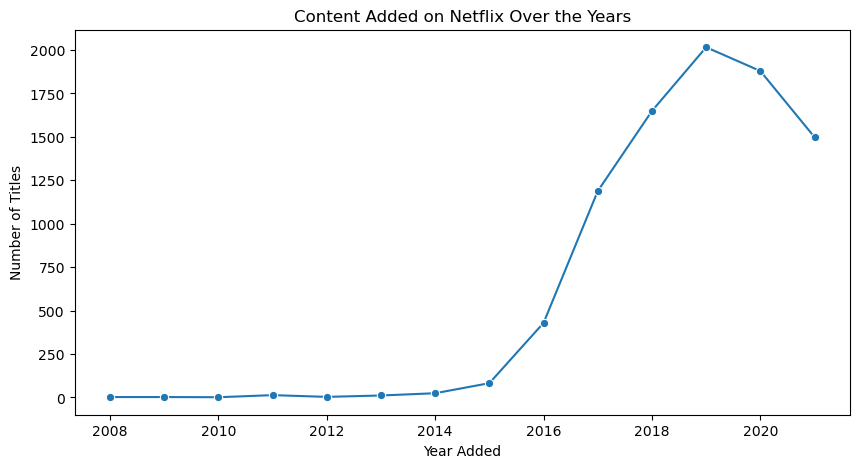

In [57]:
content_trend = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.lineplot(x=content_trend.index, y=content_trend.values, marker='o')
plt.title("Content Added on Netflix Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

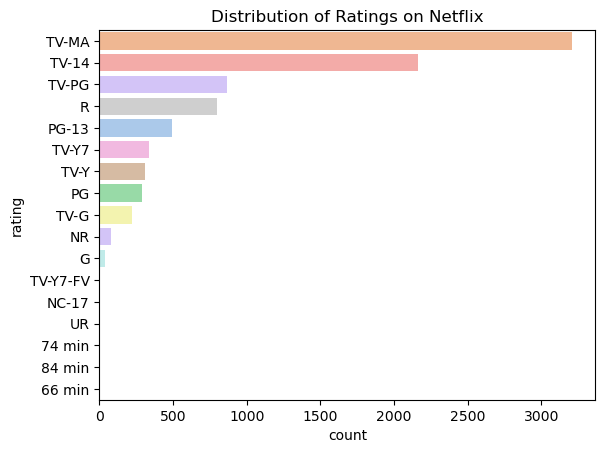

In [59]:
sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index,
    hue='rating',
    palette='pastel',
    legend=False
)
plt.title("Distribution of Ratings on Netflix")
plt.show()